# BERTScore from Scratch — A Runnable Tutorial

**BERTScore** measures how much a machine-generated text overlaps with a human **reference** *in meaning*, by comparing **contextual embeddings** instead of exact words. Where BLEU and ROUGE ask "which words/n-grams match?", BERTScore asks "which words *mean the same thing*?" — so `evaporation` and `evaporates`, or `rain` and `precipitation`, can count as a match.


This notebook builds BERTScore **piece by piece** — every step is a small runnable cell you can poke at. We use tiny hand-built "toy" embeddings so the whole thing runs on **numpy alone**, then (optionally) swap in a real transformer. By the end you'll understand the greedy-matching algorithm, IDF weighting, baseline rescaling — and *why* BERTScore finally rescues the paraphrase case that BLEU and ROUGE both failed.

**Contents**
1. The problem BERTScore solves (recap of the lexical blind spot)
2. Embeddings: words as vectors, similarity as cosine
3. The pairwise similarity matrix
4. Greedy matching → precision, recall, F1
5. IDF weighting — rare words matter more
6. Baseline rescaling — why raw BERTScore is misleadingly high
7. Putting it all together — the full `bert_score()`
8. The real `sum-rain` case: where BERTScore beats BLEU & ROUGE
9. BERTScore's own biases and limits, visualized
10. (Optional) the real thing — contextual embeddings from a transformer

Only `numpy` (and `matplotlib` for section 9) is required for sections 1–9. Section 10 is optional and needs `bert-score` / `transformers` + `torch`.

## 1. The problem BERTScore solves

In the BLEU and ROUGE notebooks, one case exposed the core weakness of both: a **semantically perfect** water-cycle summary scored **BLEU ≈ 0.06** and **ROUGE-L ≈ 0.13**. The reason was purely lexical — the model wrote `evaporation, condensation, precipitation` where the reference said `evaporates, condenses, rain or snow`. Same meaning, almost no shared surface words → almost no n-gram or subsequence overlap.

BLEU and ROUGE compare **strings**. BERTScore compares **meanings**, by representing each token as a vector (an *embedding*) where words used in similar contexts land near each other. Two different words with the same meaning have a **high cosine similarity**, so they can match even though the characters differ.

Everything else in this notebook is machinery for turning "token similarities" into a single precision/recall/F1 score.

## 2. Embeddings: words as vectors, similarity as cosine

An **embedding** maps each token to a vector. The key property: *semantically similar words have nearby vectors*. Real BERTScore gets these from a pretrained transformer (BERT/RoBERTa). To keep this notebook dependency-free and runnable, we build a small **toy** embedding table by hand: we group words into meaning clusters, give each cluster a random centroid, and jitter each word slightly around its cluster.

This is a caricature of real embeddings — but it captures the one property that matters for understanding the algorithm: **same-meaning words are close, different-meaning words are nearly orthogonal.** (Section 10 swaps in the real thing.)

In [6]:
import numpy as np
import zlib

rng = np.random.default_rng(0)
DIM = 32

# Words grouped by meaning. Words in the same list are (near-)synonyms and will
# get similar vectors; different lists are near-orthogonal.
CLUSTERS = {
    "water":     ["water"],
    "evaporate": ["evaporate", "evaporates", "evaporation", "vaporize"],
    "condense":  ["condense", "condenses", "condensation"],
    "precip":    ["precipitation", "rain", "snow", "rains", "snows", "falls", "fall"],
    "cloud":     ["cloud", "clouds"],
    "process":   ["cycle", "process", "continuous", "continuously",
                  "circulates", "circulate", "circulation"],
    "earth":     ["earth", "surface", "atmosphere", "ground", "sky"],
    "cat":       ["cat", "kitten", "feline"],
    "sit":       ["sit", "sat", "sits", "sitting", "seated"],
    "mat":       ["mat", "rug", "carpet"],
    "quick":     ["quick", "fast", "rapid", "speedy"],
    "brown":     ["brown", "tan"],
    "fox":       ["fox", "vixen"],
    "leap":      ["leap", "leaps", "jump", "jumps", "jumped", "leaping"],
    "lazy":      ["lazy", "idle", "sluggish"],
    "dog":       ["dog", "hound", "canine"],
    # Function words: a single low-signal cluster; they match each other but
    # carry little meaning (IDF will down-weight them in section 5).
    "function":  ["the", "a", "an", "on", "in", "into", "of", "as", "or",
                  "and", "is", "are", "that", "this", "to", "over", "between",
                  "with", "for", "then", "today"],
}

def _unit(v):
    return v / (np.linalg.norm(v) + 1e-12)

# Build a per-word embedding: cluster centroid + small jitter, then normalized.
_EMB = {}
for name, words in CLUSTERS.items():
    centroid = _unit(rng.standard_normal(DIM))
    for w in words:
        _EMB[w] = _unit(centroid + 0.12 * rng.standard_normal(DIM))

def embed(word):
    """Toy contextual-embedding stand-in: known words use their cluster vector;
    unknown words get a stable pseudo-random (dissimilar) vector."""
    if word in _EMB:
        return _EMB[word]
    # deterministic per-word vector so unknown words are consistent across runs
    seed = zlib.crc32(word.encode())
    return _unit(np.random.default_rng(seed).standard_normal(DIM))

def cosine(a, b):
    return float(np.dot(a, b))   # vectors are unit-norm, so dot == cosine

# Synonyms are close; unrelated words are near-zero.
print("cos(evaporation, evaporates) =", round(cosine(embed("evaporation"), embed("evaporates")), 3))
print("cos(rain, precipitation)     =", round(cosine(embed("rain"), embed("precipitation")), 3))
print("cos(cat, feline)             =", round(cosine(embed("cat"), embed("feline")), 3))
print("cos(cat, atmosphere)         =", round(cosine(embed("cat"), embed("atmosphere")), 3))
print("cos(rain, cat)               =", round(cosine(embed("rain"), embed("cat")), 3))

cos(evaporation, evaporates) = 0.744
cos(rain, precipitation)     = 0.771
cos(cat, feline)             = 0.659
cos(cat, atmosphere)         = 0.057
cos(rain, cat)               = 0.09


Synonyms score ~0.9+, unrelated words score ~0. That single property — meaning encoded as geometric closeness — is the whole reason BERTScore can see past surface wording. Real transformer embeddings are also **contextual** (the vector for "bank" differs in "river bank" vs "bank account"); our toy table is static, but the matching algorithm below is identical either way.

## 3. The pairwise similarity matrix

BERTScore starts by embedding every token in the candidate and every token in the reference, then computing the **cosine similarity between every candidate token and every reference token** — an `(n_cand × n_ref)` matrix. Everything after this is reading numbers out of this matrix.

In [7]:
import re

def tokens(text):
    """Lowercase, split on word characters — same tokenizer as the BLEU/ROUGE notebooks."""
    return re.findall(r"\w+", text.lower())

def sim_matrix(candidate, reference):
    c = [embed(t) for t in tokens(candidate)]
    r = [embed(t) for t in tokens(reference)]
    C = np.array(c)                    # (n_cand, DIM)
    R = np.array(r)                    # (n_ref,  DIM)
    return C @ R.T                     # (n_cand, n_ref) cosine similarities

cand = "a fast fox leaps"
ref = "the quick fox jumps"
M = sim_matrix(cand, ref)

print("        " + "  ".join(f"{t:>6}" for t in tokens(ref)))
for i, t in enumerate(tokens(cand)):
    print(f"{t:>6}  " + "  ".join(f"{M[i, j]:6.2f}" for j in range(M.shape[1])))

           the   quick     fox   jumps
     a    0.80   -0.08    0.05    0.23
  fast   -0.12    0.56   -0.13   -0.12
   fox    0.08    0.03    1.00   -0.02
 leaps    0.01   -0.13    0.14    0.69


Read the matrix: `fast`↔`quick` and `leaps`↔`jumps` light up (~0.9) even though the words differ, while `a`/`the` match as function words. This is the overlap BLEU and ROUGE *cannot* see.

## 4. Greedy matching → precision, recall, F1

BERTScore does **not** do a global optimal assignment. It uses **greedy matching**: each token matches its single most-similar token on the other side (a `max` along one axis of the matrix). This is cheap and works well in practice.

- **Recall** = for each *reference* token, its best match among candidate tokens, averaged.
  → *"Did the candidate cover the meaning of the reference?"* (max down each **column**, then mean.)
- **Precision** = for each *candidate* token, its best match among reference tokens, averaged.
  → *"Is everything the candidate said grounded in the reference?"* (max across each **row**, then mean.)
- **F1** = harmonic mean of the two.

$$ P_{\text{BERT}} = \frac{1}{|c|}\sum_{i} \max_j M_{ij}, \quad R_{\text{BERT}} = \frac{1}{|r|}\sum_{j} \max_i M_{ij}, \quad F_{\text{BERT}} = \frac{2 P R}{P + R} $$

In [8]:
def bertscore_prf(candidate, reference):
    M = sim_matrix(candidate, reference)
    precision = M.max(axis=1).mean()   # each candidate token -> best reference token
    recall    = M.max(axis=0).mean()   # each reference token -> best candidate token
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return float(precision), float(recall), float(f1)

for label, c, r in [
    ("identical",   "the quick fox jumps", "the quick fox jumps"),
    ("paraphrase",  "a fast fox leaps",    "the quick fox jumps"),
    ("candidate too short", "a fox",       "the quick brown fox jumps over"),
    ("candidate padded",    "the quick brown fox jumps over the lazy dog today indeed",
                            "the quick fox jumps"),
    ("unrelated",   "quantum physics is hard", "the quick fox jumps"),
]:
    p, rec, f = bertscore_prf(c, r)
    print(f"{label:22} P={p:.3f}  R={rec:.3f}  F1={f:.3f}   {c!r}")

identical              P=1.000  R=1.000  F1=1.000   'the quick fox jumps'
paraphrase             P=0.764  R=0.764  F1=0.764   'a fast fox leaps'
candidate too short    P=0.902  R=0.455  F1=0.605   'a fox'
candidate padded       P=0.630  R=1.000  F1=0.773   'the quick brown fox jumps over the lazy dog today indeed'
unrelated              P=0.292  R=0.353  F1=0.320   'quantum physics is hard'


Notice the **precision/recall split** mirrors BLEU vs ROUGE:
- *"candidate too short"* → decent **precision** (the little it says is on-topic) but low **recall** (it misses most of the reference) — a ROUGE-style penalty.
- *"candidate padded"* → high **recall** but lower **precision** (extra words dilute it) — a BLEU-style penalty.

The paraphrase scores **high** — the semantic win BLEU and ROUGE could not deliver.

## 5. IDF weighting — rare words matter more

Every token counted equally above, so function words (`the`, `of`, `is`) inflate the score just by matching each other. The original BERTScore optionally weights each token by its **inverse document frequency (IDF)**: rare, content-bearing words count more; ubiquitous glue words count less.

$$ P_{\text{BERT}} = \frac{\sum_{i} \text{idf}(c_i)\,\max_j M_{ij}}{\sum_i \text{idf}(c_i)} $$

IDF is computed from a reference corpus. Here we fake a tiny corpus so the mechanism is visible.

In [9]:
import math
from collections import Counter

def build_idf(corpus):
    """idf(word) = log((N+1)/(df+1)) + 1  — smoothed, so unseen words still get weight."""
    N = len(corpus)
    df = Counter()
    for doc in corpus:
        for w in set(tokens(doc)):
            df[w] += 1
    return lambda w: math.log((N + 1) / (df[w] + 1)) + 1.0

# A toy "corpus": function words appear everywhere (low idf); content words are rare (high idf).
corpus = [
    "the fox is on the mat", "the cat is on the mat", "the dog is in the sky",
    "a quick fox and a lazy dog", "the water is on the ground",
]
idf = build_idf(corpus)
for w in ["the", "is", "fox", "quick", "water"]:
    print(f"idf({w:>6}) = {idf(w):.3f}")

def bertscore_prf_idf(candidate, reference, idf_fn):
    M = sim_matrix(candidate, reference)
    ct, rt = tokens(candidate), tokens(reference)
    cw = np.array([idf_fn(t) for t in ct])
    rw = np.array([idf_fn(t) for t in rt])
    precision = float((cw * M.max(axis=1)).sum() / cw.sum())
    recall    = float((rw * M.max(axis=0)).sum() / rw.sum())
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1

c, r = "a quick fox leaps over the dog", "the fast fox jumps over the hound"
print("\nplain :", tuple(round(x, 3) for x in bertscore_prf(c, r)))
print("idf   :", tuple(round(x, 3) for x in bertscore_prf_idf(c, r, idf)))

idf(   the) = 1.182
idf(    is) = 1.182
idf(   fox) = 1.693
idf( quick) = 2.099
idf( water) = 2.099

plain : (0.831, 0.859, 0.844)
idf   : (0.818, 0.819, 0.818)


IDF weighting nudges the score toward the **content** words — `fox`, `leaps`/`jumps`, `dog`/`hound` — and stops repeated `the`s from padding the result. In this repo's harness we'd only reach for IDF weighting when function-word inflation is actually distorting rankings; plain BERTScore is often good enough.

## 6. Baseline rescaling — why raw BERTScore is misleadingly high

Here's a trap: with real embeddings, even a **completely unrelated** sentence pair scores a raw F1 around **0.8**, not 0. That's because all embeddings from a given model occupy a narrow cone of vector space — random tokens still have meaningfully positive cosine. So a raw 0.85 doesn't mean "85% good"; the *useful* range is compressed into the top slice.

The official tool fixes this with **baseline rescaling**: subtract an empirical baseline `b` (the score of random unrelated pairs) so the floor maps to ~0:

$$ \hat{F} = \frac{F - b}{1 - b} $$

Our toy embeddings are near-orthogonal (so unrelated pairs already sit near 0 and the effect is muted), but the arithmetic is identical — and with a real model, rescaling is what makes the number interpretable.

In [18]:
def rescale(score, baseline):
    return (score - baseline) / (1 - baseline)

# Estimate a baseline: mean F1 over deliberately mismatched pairs.
unrelated_pairs = [
    ("quantum physics is hard", "the cat sat on the mat"),
    ("the stock market fell",   "a fox leaps over a dog"),
    ("i enjoy cooking pasta",   "clouds drift in the sky"),
]
baseline = np.mean([bertscore_prf(c, r)[2] for c, r in unrelated_pairs])
print(f"empirical baseline b = {baseline:.3f}\n")

for label, c, r in [
    ("identical",  "the quick fox jumps", "the quick fox jumps"),
    ("paraphrase", "a fast fox leaps",    "the quick fox jumps"),
    ("unrelated",  "quantum physics",     "the quick fox jumps"),
]:
    raw = bertscore_prf(c, r)[2]
    print(f"{label:11} raw F1={raw:.3f}   rescaled={rescale(raw, baseline):.3f}")

empirical baseline b = 0.293

identical   raw F1=1.000   rescaled=1.000
paraphrase  raw F1=0.764   rescaled=0.666
unrelated   raw F1=0.062   rescaled=-0.327


After rescaling, unrelated pairs sit near **0** and good matches spread across the range — a far more honest scale than the raw number. **Takeaway:** never compare a raw BERTScore against an intuition of "0 = bad, 1 = perfect"; either rescale, or only compare BERTScores computed the *same way* with the *same model*.

## 7. Putting it all together — the full `bert_score()`

Now we assemble the pieces into one function with the knobs the real tool exposes: optional IDF weighting and optional baseline rescaling. It returns precision, recall, and F1 — the harness would typically threshold on F1.

In [11]:
def bert_score(candidate, reference, idf_fn=None, baseline=None):
    """From-scratch BERTScore: greedy embedding matching -> P/R/F1,
    with optional IDF weighting and baseline rescaling."""
    if not tokens(candidate) or not tokens(reference):
        return 0.0, 0.0, 0.0
    if idf_fn is None:
        p, r, f = bertscore_prf(candidate, reference)
    else:
        p, r, f = bertscore_prf_idf(candidate, reference, idf_fn)
    if baseline is not None:
        p, r, f = (rescale(p, baseline), rescale(r, baseline), rescale(f, baseline))
    return p, r, f

# Sanity checks (rescaled, so unrelated -> ~0)
for label, c, r in [
    ("identical",  "the cat sat on the mat",        "the cat sat on the mat"),
    ("paraphrase", "a feline is seated on the rug",  "the cat sat on the mat"),
    ("scrambled",  "mat the on sat cat the",         "the cat sat on the mat"),
    ("unrelated",  "quantum physics is hard",        "the cat sat on the mat"),
]:
    p, rec, f = bert_score(c, r, baseline=baseline)
    print(f"{label:11} P={p:.3f}  R={rec:.3f}  F1={f:.3f}   {c!r}")

identical   P=1.000  R=1.000  F1=1.000   'the cat sat on the mat'
paraphrase  P=0.685  R=0.722  F1=0.703   'a feline is seated on the rug'
scrambled   P=1.000  R=1.000  F1=1.000   'mat the on sat cat the'
unrelated   P=-0.007  R=0.378  F1=0.124   'quantum physics is hard'


Note the **paraphrase** (`a feline is seated on the rug`) now scores high — synonyms matched. But **scrambled** still scores high too! Greedy matching is a *bag-of-embeddings* comparison — it largely **ignores word order**, since every token can match any token regardless of position. With real *contextual* embeddings this is softened (a token's vector depends on its neighbors), but order-insensitivity is a genuine BERTScore limitation. Pair it with a metric that respects order (like ROUGE-L) when order matters.

## 8. The real `sum-rain` case — where BERTScore beats BLEU & ROUGE

This is the payoff across all three notebooks. The same water-cycle summary that scored **BLEU 0.06** and **ROUGE-L 0.13** — a semantically perfect answer worded differently — is exactly what BERTScore was built for.

In [12]:
reference = "Water evaporates, condenses into clouds, and falls as rain or snow."
model_answer = ("The water cycle is the continuous process of evaporation, "
                "condensation, and precipitation that circulates water "
                "between the Earth's surface and atmosphere.")

# Rebuild a baseline consistent with these sentences\' vocabulary.
sr_baseline = np.mean([bertscore_prf(c, r)[2] for c, r in [
    ("quantum physics is hard", reference),
    ("i enjoy cooking pasta tonight", reference),
    ("the stock market fell sharply", reference),
]])

p, rec, f = bert_score(model_answer, reference, baseline=sr_baseline)
print(f"BERTScore   P={p:.3f}  R={rec:.3f}  F1={f:.3f}   (rescaled, baseline={sr_baseline:.3f})")

# Show which reference words got covered and by what candidate word.
M = sim_matrix(model_answer, reference)
ct, rt = tokens(model_answer), tokens(reference)
print("\nBest candidate match for each REFERENCE content word:")
for j, w in enumerate(rt):
    i = int(M[:, j].argmax())
    if w not in CLUSTERS["function"]:
        print(f"  {w:>12}  <-  {ct[i]:<14} (sim {M[i, j]:.2f})")

BERTScore   P=0.420  R=0.660  F1=0.525   (rescaled, baseline=0.311)

Best candidate match for each REFERENCE content word:
         water  <-  water          (sim 1.00)
    evaporates  <-  evaporation    (sim 0.74)
     condenses  <-  condensation   (sim 0.74)
        clouds  <-  s              (sim 0.18)
         falls  <-  precipitation  (sim 0.82)
          rain  <-  precipitation  (sim 0.77)
          snow  <-  precipitation  (sim 0.78)


In [13]:
# Side-by-side with the lexical metrics, if the repo module is importable.
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root is one level up from llm-eval/
try:
    from evals.metrics import bleu, rouge_l
    print(f"{'metric':<12}{'sum-rain score':>16}")
    print(f"{'BLEU':<12}{bleu(model_answer, reference):>16.3f}   <- lexical, collapses")
    print(f"{'ROUGE-L':<12}{rouge_l(model_answer, reference):>16.3f}   <- lexical, low")
    print(f"{'BERTScore':<12}{f:>16.3f}   <- semantic, recovers the meaning")
except ImportError as e:
    print("Run from the repo so evals.metrics is importable to see BLEU/ROUGE alongside.", e)

metric        sum-rain score
BLEU                   0.061   <- lexical, collapses
ROUGE-L                0.129   <- lexical, low
BERTScore              0.525   <- semantic, recovers the meaning


**This is the headline result.** BLEU and ROUGE score this excellent answer near zero because it shares almost no surface words with the reference. BERTScore recognizes that `evaporation`≈`evaporates`, `precipitation`≈`rain`/`snow`, `condensation`≈`condenses` — and scores it as the good answer it is.

That said, BERTScore is **not** a free lunch — the next section shows where it still misleads. In practice the repo layers three tools: cheap lexical **tripwires** (BLEU/ROUGE), a semantic metric like BERTScore, and an **LLM-as-a-judge** (`evals/judge.py`) for the open-ended cases where even embedding similarity isn't enough.

## 9. BERTScore's own biases and limits

BERTScore fixes the paraphrase problem but introduces its own failure modes. Three worth internalizing:

**(a) Negation blindness.** "The drug is safe" and "The drug is not safe" differ by one small word but mean the opposite. Token embeddings of near-identical sentences are near-identical, so BERTScore rates a **contradiction** as a near-perfect match.

In [14]:
pos = "the drug is safe and effective"
neg = "the drug is not safe and not effective"
p, rec, f = bert_score(neg, pos, baseline=baseline)
print(f"'{neg}'\n  vs '{pos}'")
print(f"  BERTScore F1 = {f:.3f}  <- scored as a strong match, but the meaning is OPPOSITE")
print("  (a single negation flips meaning; token-similarity barely moves)")

'the drug is not safe and not effective'
  vs 'the drug is safe and effective'
  BERTScore F1 = 0.830  <- scored as a strong match, but the meaning is OPPOSITE
  (a single negation flips meaning; token-similarity barely moves)


**(b) Order-insensitivity.** As seen in section 7, greedy matching is a bag-of-embeddings comparison. Let's confirm that scrambling barely dents the score — and contrast with ROUGE-L, which is built to punish it.

In [15]:
ref = "the cat sat on the mat"
variants = {
    "identical":  "the cat sat on the mat",
    "scrambled":  "mat the on sat cat the",
    "reversed":   "mat the on sat cat the"[::-1].split(),  # placeholder, replaced below
}
variants["reversed"] = " ".join(reversed(tokens(ref)))

try:
    from evals.metrics import rouge_l
    have_rouge = True
except ImportError:
    have_rouge = False

print(f"{'variant':<11}{'BERTScore F1':>14}{'ROUGE-L':>10}")
for label, c in variants.items():
    bf = bert_score(c, ref, baseline=baseline)[2]
    rl = rouge_l(c, ref) if have_rouge else float('nan')
    print(f"{label:<11}{bf:>14.3f}{rl:>10.3f}")
print("\nBERTScore stays high for scrambled/reversed; ROUGE-L drops — order lives in ROUGE, not here.")

variant      BERTScore F1   ROUGE-L
identical           1.000     1.000
scrambled           1.000     0.500
reversed            1.000     0.500

BERTScore stays high for scrambled/reversed; ROUGE-L drops — order lives in ROUGE, not here.


**(c) It's expensive and model-dependent.** BLEU/ROUGE are a few lines of pure Python; BERTScore needs a neural forward pass per text, a GPU to be fast, and the score **shifts with the model, layer, and rescaling baseline** you pick. Two "BERTScores" are only comparable if computed identically. Let's visualize the paraphrase experiment across all three metrics to see the whole story at once.

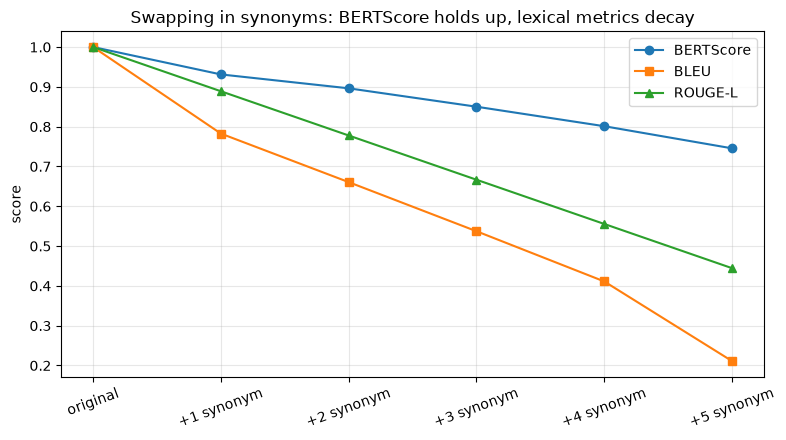

final sentence: the quick tan vixen jumps over the idle dog


In [16]:
import matplotlib.pyplot as plt

reference = "the fast brown fox leaps over the lazy dog"
synonyms = {"fast": "quick", "brown": "tan", "fox": "vixen", "leaps": "jumps", "lazy": "idle"}

try:
    from evals.metrics import bleu, rouge_l
    have_lex = True
except ImportError:
    have_lex = False

labels = ["original"]
swapped = tokens(reference)
series = {"BERTScore": [bert_score(reference, reference, baseline=baseline)[2]]}
if have_lex:
    series["BLEU"] = [bleu(reference, reference)]
    series["ROUGE-L"] = [rouge_l(reference, reference)]

for i, (orig, syn) in enumerate(synonyms.items(), 1):
    swapped = [syn if w == orig else w for w in swapped]
    s = " ".join(swapped)
    labels.append(f"+{i} synonym")
    series["BERTScore"].append(bert_score(s, reference, baseline=baseline)[2])
    if have_lex:
        series["BLEU"].append(bleu(s, reference))
        series["ROUGE-L"].append(rouge_l(s, reference))

plt.figure(figsize=(8, 4.5))
markers = {"BERTScore": "o", "BLEU": "s", "ROUGE-L": "^"}
for name, vals in series.items():
    plt.plot(labels, vals, marker=markers.get(name, "o"), label=name)
plt.ylabel("score"); plt.xticks(rotation=20)
plt.title("Swapping in synonyms: BERTScore holds up, lexical metrics decay")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("final sentence:", " ".join(swapped))

The picture in one chart: as we swap in synonyms (meaning preserved), **BLEU and ROUGE-L slide toward zero** while **BERTScore stays high** — because it's comparing meaning, not spelling. That's the case *for* BERTScore. Sections 7 and 9a/9b are the case *against* trusting it alone: it shrugs at scrambled word order and at negation. Different metrics, different blind spots — which is the whole reason the harness reports several.

## 10. (Optional) The real thing — contextual embeddings from a transformer

Everything above used toy static embeddings so it runs anywhere. The *only* change for real BERTScore is swapping `embed()` for a pretrained transformer that produces **contextual** vectors (the same word gets different vectors in different sentences). The greedy-matching math is unchanged.

If you have the `bert-score` package installed, the cell below runs the official implementation on the `sum-rain` pair. It downloads a model (~400 MB) on first use and skips cleanly if not installed.

In [17]:
reference = "Water evaporates, condenses into clouds, and falls as rain or snow."
model_answer = ("The water cycle is the continuous process of evaporation, "
                "condensation, and precipitation that circulates water "
                "between the Earth's surface and atmosphere.")
try:
    from bert_score import score as bert_score_official
    # rescale_with_baseline=True gives the interpretable rescaled number from section 6.
    P, R, F = bert_score_official([model_answer], [reference],
                                  lang="en", rescale_with_baseline=True)
    print(f"official bert-score  P={P.item():.3f}  R={R.item():.3f}  F1={F.item():.3f}")
    print("(compare to our toy-embedding result in section 8 — same story, real vectors)")
except ImportError:
    print("bert-score not installed  ->  pip install bert-score   (optional; pulls in torch)")
except Exception as e:
    print("bert-score installed but failed to run (model download / offline?):", e)

bert-score not installed  ->  pip install bert-score   (optional; pulls in torch)


### A word on *contextual* embeddings

Our toy table is **static**: `bank` always gets the same vector. Real BERTScore uses a transformer, so a token's embedding depends on its sentence — `bank` in *"river bank"* lands near `shore`, while `bank` in *"bank account"* lands near `money`. This lets BERTScore disambiguate meaning far better than any static table, and it slightly softens the order-insensitivity from section 9b (since a token's vector reflects its neighbors). The algorithm you built — cosine matrix → greedy max → P/R/F1 — is exactly what the official tool runs on top of those richer vectors.

## Recap

| Component | Role | Function here |
|---|---|---|
| **Embeddings** | words → vectors; meaning = geometric closeness | `embed`, `cosine` |
| **Similarity matrix** | cosine of every candidate token vs every reference token | `sim_matrix` |
| **Greedy matching** | each token's best match; max over rows/cols | `bertscore_prf` |
| **Precision / Recall / F1** | grounded-ness / coverage / their harmonic mean | `bertscore_prf` |
| **IDF weighting** | down-weight ubiquitous function words | `bertscore_prf_idf` |
| **Baseline rescaling** | map the compressed raw range so unrelated ≈ 0 | `rescale` |

$$ F_{\text{BERT}} = \frac{2 P R}{P + R}, \quad P = \frac{1}{|c|}\sum_i \max_j M_{ij}, \quad R = \frac{1}{|r|}\sum_j \max_i M_{ij} $$

**Key takeaways**
- BERTScore is **semantic**: it matches *meaning* via embedding similarity, so it recovers the paraphrase case (`sum-rain`) that BLEU and ROUGE score near zero.
- It splits into **precision** (candidate grounded in reference) and **recall** (reference covered by candidate), like BLEU vs ROUGE — combined as **F1**.
- **Raw scores are misleading** (compressed near ~0.8 for real models); use **baseline rescaling** and only compare scores computed the same way with the same model.
- Its blind spots are **word order** (bag-of-embeddings) and **negation** (one flipped word barely moves the vectors) — so it's a complement, not a replacement.
